## Test of Functions

In [1]:
%reset -f
%matplotlib widget
from main import range_km, aero_cost
from freewake_parse import freewake_input
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from main import power_eqn, curve_fit
from scipy.interpolate import interp1d

In [2]:
wingspan = 1.9422 # 1 m
mid_chord = 0.10577 # 15 cm
tip_chord = 0.07833 # 15 cm
w_flange = 0.005565
t_flange = 0.0067967
t_web = 0.0074199
t_skin_root = 0.000938 # 1 mm
t_skin_mid = 0.00031859
t_skin_tip = 0.00148899
mid_twist = -0.901387 # 0 deg
tip_twist = -0.690297 # 0 deg
skin_index = 1
spar_index = 1

fw_folder = r"C:\Users\mayar\Documents\Ryerson\AALOFT\Freewake(in_use)"
freewake_input(fw_folder, wingspan, mid_chord, tip_chord, mid_twist, tip_twist, 5*9.81, 0, 0)

In [3]:
# perf_output_path = r"C:/Users/mayar/Documents/Ryerson/AALOFT/Freewake(in_use)/output/Performance.txt"
perf_output_path = r"C:\Users\mayar\Documents\Ryerson\AALOFT\Freewake(in_use)\output\Performance.txt"
df_performance = pd.read_csv(perf_output_path, sep=r'\s+', skiprows=3)

df_clean = df_performance.dropna()
df_clean = df_clean[1:17]
df_vinf = df_clean['Vinf']
df_preq = df_clean['Preq']
coefficients, _ = curve_fit(power_eqn, df_vinf, df_preq)
a_fit, b_fit, c_fit = coefficients

# Find speed for max range
V_maxR = np.sqrt(c_fit/a_fit)

# Find power required at speed for max range
Preq = power_eqn(V_maxR, a_fit, b_fit, c_fit)

f_aoa_max = interp1d(df_clean['Vinf'],df_clean['alpha'],kind='linear')
# try:
aoa_maxR = f_aoa_max(V_maxR)
# except ValueError:
# aoa_maxR = f_aoa_max(min(df_clean['Vinf']))

range_est = range_km(V_maxR, Preq)

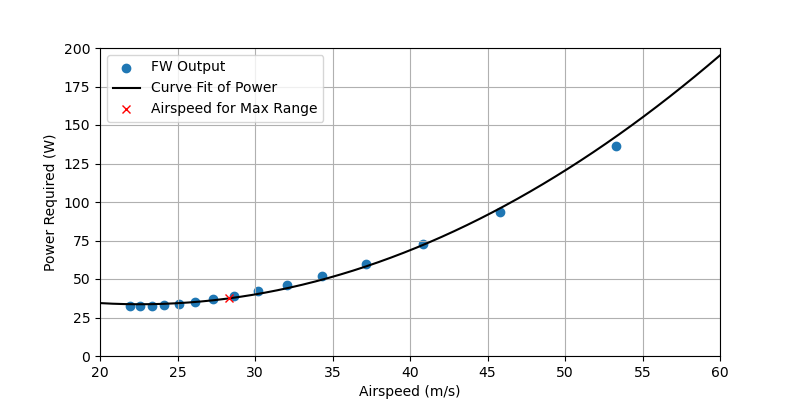

In [4]:
fig, ax1 = plt.subplots(1,1,figsize=(8,4))

Vinf = np.linspace(20,60,50)
Preq_V = power_eqn(Vinf, a_fit, b_fit, c_fit)

ax1.scatter(df_vinf, df_preq, label='FW Output')
ax1.plot(Vinf,Preq_V, 'black', label='Curve Fit of Power')
ax1.plot(V_maxR, Preq, 'rx', label='Airspeed for Max Range')
ax1.grid()
ax1.set_ylabel('Power Required (W)')
ax1.set_xlabel('Airspeed (m/s)')
ax1.set_xlim([20,60])
ax1.set_ylim([0,200])
ax1.legend()

plt.show()

In [5]:
aoa_col = ['index','xo','yo','zo','cn','cl','cy','cd','A','B','C','S','span','chord','nu','epsilon','psi','phiLE','#']
force_output_path = r"C:\Users\mayar\Documents\Ryerson\AALOFT\Freewake(in_use)\output\AOA5.50.txt"
df_force = pd.read_csv(force_output_path, skiprows=4, sep=r'\s+', nrows=8, header=None, names=aoa_col)

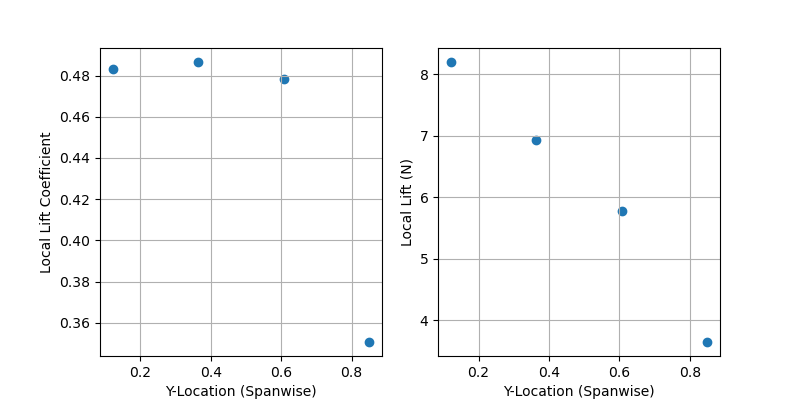

In [8]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(8,4))

ax1.scatter(df_force['yo'], df_force['cl'], label='FW Output')
ax1.grid()
ax1.set_xlabel('Y-Location (Spanwise)')
ax1.set_ylabel('Local Lift Coefficient')

ax2.scatter(df_force['yo'], 0.5*1.225*(28.65**2)*df_force['S']*df_force['cl'], label='FW Output')
ax2.grid()
ax2.set_xlabel('Y-Location (Spanwise)')
ax2.set_ylabel('Local Lift (N)')

plt.show()